# DataXID Profiling - Benchmark Tests

Bu notebook, **DataXID** (Polars tabanlı modern profiling aracı) ile piyasadaki Pandas tabanlı kütüphanelerin performans ve hız karşılaştırmalarını içermektedir.

**Hedefimiz:** Milyonlarca satırlık devasa veri setlerinde (1 Milyon - 100 Milyon satır arası) klasik veri analizi araçlarının darboğaza girdiği noktaları tespit etmek ve **DataXID'nin bellek dostu, yüksek hızlı mimarisini** dürüst metriklerle kanıtlamaktır.

##  Test Edilen Senaryo
* **DataXID vs. Pandas:** Klasik ve hantal mimariye karşı Polars motorunun hızı.

<table style="width: 100%; text-align: left; line-height: 1.6; table-layout: fixed; word-wrap: break-word;">
  <thead>
    <tr style="border-bottom: 2px solid #ccc;">
      <th style="padding: 10px; width: 22%;"> Özellik / İşlem</th>
      <th style="padding: 10px; width: 19%;"> YData (Default)</th>
      <th style="padding: 10px; width: 19%;"> YData (Minimal)</th>
      <th style="padding: 10px; width: 20%;"> DataXID (Complete)</th>
      <th style="padding: 10px; width: 20%;"> DataXID (Overview)</th>
    </tr>
  </thead>
  <tbody>
    <tr style="border-bottom: 1px solid #ddd;">
      <td style="padding: 10px;"><b>Tip Çıkarımı</b></td>
      <td style="padding: 10px;"><code>infer_dtypes: true</code> (Tahmin eder)</td>
      <td style="padding: 10px;"><code>infer_dtypes: false</code> (Kapalı)</td>
      <td style="padding: 10px;">Otomatik tür yönetimi aktif</td>
      <td style="padding: 10px;">Otomatik tür yönetimi aktif</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td style="padding: 10px;"><b>Korelasyonlar</b></td>
      <td style="padding: 10px;"><code>auto: calculate: true</code></td>
      <td style="padding: 10px;">Tüm korelasyonlar <code>false</code></td>
      <td style="padding: 10px;">Phi_k, Pearson, Spearman, Kendall, Cramér's V</td>
      <td style="padding: 10px;">Tamamen atlanır</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td style="padding: 10px;"><b>Etkileşimler</b></td>
      <td style="padding: 10px;"><code>continuous: true</code></td>
      <td style="padding: 10px;"><code>continuous: false</code> (Kapalı)</td>
      <td style="padding: 10px;">Scatter + Boxplot hesaplanır</td>
      <td style="padding: 10px;">Tamamen atlanır</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td style="padding: 10px;"><b>Eksik Veri Görselleri</b></td>
      <td style="padding: 10px;">Bar, Matrix, Heatmap <code>true</code></td>
      <td style="padding: 10px;">Hepsi <code>false</code> (Kapatılır)</td>
      <td style="padding: 10px;">ECharts ile otomatik (kapatılamaz)</td>
      <td style="padding: 10px;">ECharts ile otomatik (kapatılamaz)</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td style="padding: 10px;"><b>Kategorik Metin</b></td>
      <td style="padding: 10px;">Uzunluk, karakter, kelime <code>true</code></td>
      <td style="padding: 10px;">Uzunluk, karakter, kelime <code>false</code></td>
      <td style="padding: 10px;">Uzunluk, kelime, karakter frekansı, length histogram</td>
      <td style="padding: 10px;">Uzunluk, kelime - karakter frekansı ve histogram atlanır</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td style="padding: 10px;"><b>Yinelenen Satır Örneği</b></td>
      <td style="padding: 10px;">Gösterir (head: 10)</td>
      <td style="padding: 10px;">Göstermez (head: 0)</td>
      <td style="padding: 10px;">Hesaplanır ve gösterilir </td>
      <td style="padding: 10px;">Atlanır</td>
    </tr>
    <tr>
      <td style="padding: 10px;"><b>Örneklem Alanları</b></td>
      <td style="padding: 10px;">Head/Tail: 10</td>
      <td style="padding: 10px;">Head/Tail: 0 (Kapatılır)</td>
      <td style="padding: 10px;">Head/Tail: 10 (kapatılamaz) </td>
      <td style="padding: 10px;">Head/Tail: 10 (kapatılamaz) </td>
    </tr>
  </tbody>
</table>

In [2]:
!git clone https://github.com/dataxid/dataxid-profiling.git
!pip install -e ./dataxid-profiling
!pip install ydata-profiling psutil matplotlib

Archive:  dataxid-profiling.zip
   creating: dataxid-profiling/
   creating: dataxid-profiling/.git/
  inflating: dataxid-profiling/.git/config  
  inflating: dataxid-profiling/.git/description  
  inflating: dataxid-profiling/.git/HEAD  
   creating: dataxid-profiling/.git/hooks/
  inflating: dataxid-profiling/.git/hooks/applypatch-msg.sample  
  inflating: dataxid-profiling/.git/hooks/commit-msg.sample  
  inflating: dataxid-profiling/.git/hooks/fsmonitor-watchman.sample  
  inflating: dataxid-profiling/.git/hooks/post-update.sample  
  inflating: dataxid-profiling/.git/hooks/pre-applypatch.sample  
  inflating: dataxid-profiling/.git/hooks/pre-commit.sample  
  inflating: dataxid-profiling/.git/hooks/pre-merge-commit.sample  
  inflating: dataxid-profiling/.git/hooks/pre-push.sample  
  inflating: dataxid-profiling/.git/hooks/pre-rebase.sample  
  inflating: dataxid-profiling/.git/hooks/pre-receive.sample  
  inflating: dataxid-profiling/.git/hooks/prepare-commit-msg.sample  
  infl

In [3]:
%%writefile data_generator.py
import pandas as pd
import numpy as np

def generate_dummy_data(n_rows):
    """10 Kolonlu Sentetik Veri Üretici Modülü"""
    print(f"\n[+] {n_rows:,} satırlık sentetik veri üretiliyor...")
    np.random.seed(42)

    # Sayısal veriler: float32 (5 adet)
    data = {f"num_col_{i}": np.random.randn(n_rows).astype(np.float32) for i in range(5)}
    df = pd.DataFrame(data)

    # Metin verileri: PyArrow ile (3 adet)
    for i in range(3):
        df[f"cat_col_{i}"] = pd.Series(np.random.choice(["A", "B", "C", "D"], n_rows), dtype="string[pyarrow]")

    # Boolean veriler (2 adet)
    for i in range(2):
        df[f"bool_col_{i}"] = np.random.choice([True, False], n_rows)

    return df

Writing data_generator.py


In [4]:
%%writefile benchmark_runner.py
import time
import gc
import os
import psutil
from dataxid_profiling import ProfileReport as DataxidProfile, ProfileConfig
from ydata_profiling import ProfileReport as PandasProfile

def get_memory_usage_mb():
    """Mevcut sürecin RAM kullanımını MB cinsinden döndürür."""
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 * 1024)

def run_benchmarks(df, rows):
    """Süre ve RAM tüketimini ölçen test modülü."""
    # DataXID Testi
    print(f"--> DataXID Profiling test ediliyor ({rows:,} satır)...")
    dx_config = ProfileConfig(title=f"DataXID {rows}", mode="overview")

    mem_before_dx = get_memory_usage_mb()
    t0 = time.time()

    dx_report = DataxidProfile(df, config=dx_config)
    dx_report.to_dict()

    dx_time = time.time() - t0
    dx_mem = max(0, get_memory_usage_mb() - mem_before_dx)
    print(f"    DataXID Süresi: {dx_time:.1f} sn | Ekstra RAM Yükü: {dx_mem:.1f} MB")

    del dx_report
    gc.collect()

    # Pandas (YData) Testi
    print(f"--> Pandas Profiling test ediliyor ({rows:,} satır)...")
    mem_before_yd = get_memory_usage_mb()
    t0 = time.time()

    try:
        yd_report = PandasProfile(df, title=f"Pandas {rows}", minimal=True)
        yd_report.get_description()
        yd_time = time.time() - t0
        yd_mem = max(0, get_memory_usage_mb() - mem_before_yd)
        print(f"    Pandas Süresi: {yd_time:.1f} sn | Ekstra RAM Yükü: {yd_mem:.1f} MB")
        del yd_report
    except Exception as e:
        print(f"    [!] Pandas bu basamakta OOM hatası verdi/çöktü: {e}")
        yd_time = 0
        yd_mem = 0

    gc.collect()

    return dx_time, yd_time, dx_mem, yd_mem

Writing benchmark_runner.py


In [5]:
%%writefile visualizer.py
import matplotlib.pyplot as plt
import numpy as np
import psutil
import platform

def get_env_string():
    ram_gb = round(psutil.virtual_memory().total / (1024**3))
    cpu_info = platform.processor() or "Colab Cloud CPU"
    return f"Benchmarking Environment ... {cpu_info} | Memory {ram_gb} GB"

def draw_comparison_chart(row_counts, dataxid_times, pandas_times):
    """Hız Karşılaştırma Grafiği"""
    print("\n[+] Süre karşılaştırma grafiği çiziliyor...")
    labels = [f"{r//1_000_000}M" for r in row_counts]
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(11, 6))
    rects1 = ax.bar(x - width/2, dataxid_times, width, label='DataXID (Polars)', color='#4472C4')
    rects2 = ax.bar(x + width/2, pandas_times, width, label='Pandas (YData)', color='#ED7D31')

    ax.set_ylabel('Processing time (sec)', fontweight='bold')
    ax.set_xlabel('Number of rows', fontweight='bold')
    ax.set_title('Speed Benchmark: DataXID vs. Pandas (10 Columns)', fontweight='bold', pad=20, fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend(loc='upper left', frameon=False)
    ax.grid(axis='y', linestyle='-', alpha=0.3)

    ax.bar_label(rects1, padding=3, fmt='%.1f')
    for rect in rects2:
        height = rect.get_height()
        if height == 0:
            ax.annotate('CRASHED\n(OOM)', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', color='red', fontweight='bold')
        else:
            ax.annotate(f'{height:.1f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

    plt.figtext(0.12, 0.02, get_env_string(), ha="left", fontsize=9)
    plt.subplots_adjust(bottom=0.18)
    plt.savefig("benchmark_speed.png", dpi=300)
    plt.show()

def draw_memory_chart(row_counts, dataxid_mems, pandas_mems):
    """RAM Tüketimi Karşılaştırma Grafiği"""
    print("[+] RAM tüketimi karşılaştırma grafiği çiziliyor...")
    labels = [f"{r//1_000_000}M" for r in row_counts]
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(11, 6))
    rects1 = ax.bar(x - width/2, dataxid_mems, width, label='DataXID Memory (MB)', color='#70AD47')
    rects2 = ax.bar(x + width/2, pandas_mems, width, label='Pandas Memory (MB)', color='#FFC000')

    ax.set_ylabel('Memory Overhead (MB)', fontweight='bold')
    ax.set_xlabel('Number of rows', fontweight='bold')
    ax.set_title('Memory Benchmark: DataXID vs. Pandas (10 Columns)', fontweight='bold', pad=20, fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend(loc='upper left', frameon=False)
    ax.grid(axis='y', linestyle='-', alpha=0.3)

    ax.bar_label(rects1, padding=3, fmt='%.1f')
    for rect in rects2:
        height = rect.get_height()
        if height == 0:
            ax.annotate('CRASHED', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', color='red', fontweight='bold')
        else:
            ax.annotate(f'{height:.1f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

    plt.figtext(0.12, 0.02, get_env_string(), ha="left", fontsize=9)
    plt.subplots_adjust(bottom=0.18)
    plt.savefig("benchmark_memory.png", dpi=300)
    plt.show()

Writing visualizer.py



[+] 1,000,000 satırlık sentetik veri üretiliyor...
--> DataXID Profiling test ediliyor (1,000,000 satır)...
    DataXID Süresi: 0.9 sn | Ekstra RAM Yükü: 399.0 MB
--> Pandas Profiling test ediliyor (1,000,000 satır)...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:03<00:00,  2.52it/s]


    Pandas Süresi: 6.0 sn | Ekstra RAM Yükü: 418.5 MB

[+] 10,000,000 satırlık sentetik veri üretiliyor...
--> DataXID Profiling test ediliyor (10,000,000 satır)...
    DataXID Süresi: 6.4 sn | Ekstra RAM Yükü: 1953.4 MB
--> Pandas Profiling test ediliyor (10,000,000 satır)...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

...


100%|██████████| 10/10 [07:44<00:00, 46.44s/it]


    Pandas Süresi: 465.1 sn | Ekstra RAM Yükü: 11943.5 MB

[+] 100,000,000 satırlık sentetik veri üretiliyor...
--> DataXID Profiling test ediliyor (100,000,000 satır)...
    DataXID Süresi: 69.2 sn | Ekstra RAM Yükü: 11561.8 MB
--> Pandas Profiling test ediliyor (100,000,000 satır)...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [09:36<00:00, 57.63s/it]  


    Pandas Süresi: 577.0 sn | Ekstra RAM Yükü: 17663.7 MB

[+] Süre karşılaştırma grafiği çiziliyor...


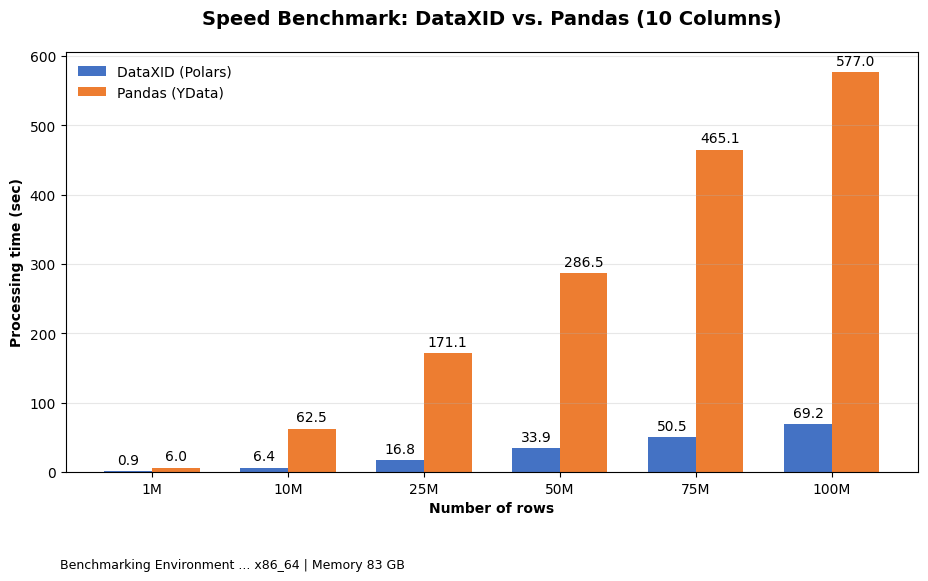

[+] RAM tüketimi karşılaştırma grafiği çiziliyor...


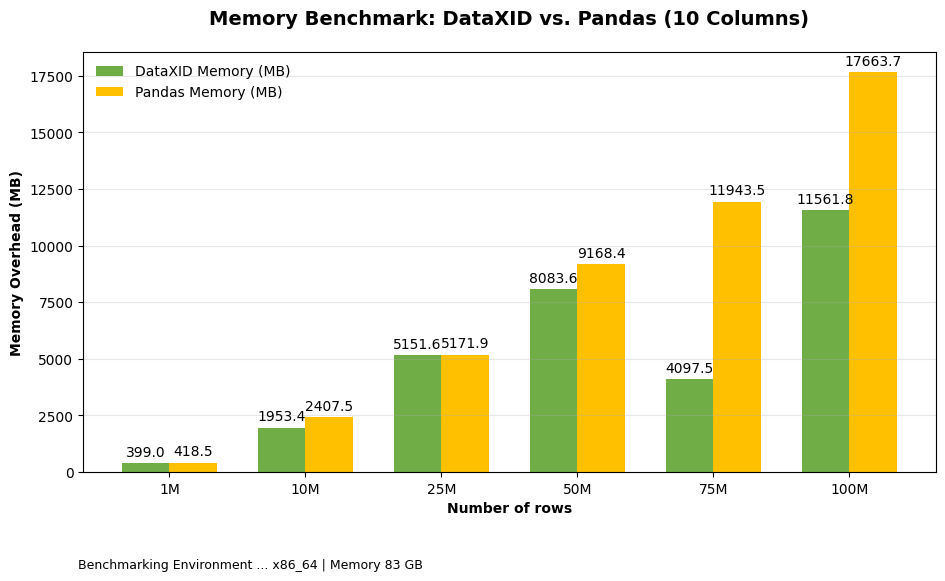

In [6]:
import sys
import os
import gc

# Dataxid yolları
colab_src_path = '/content/dataxid-profiling/src'
colab_root_path = '/content/dataxid-profiling'

for path in [colab_src_path, colab_root_path]:
    if os.path.exists(path) and path not in sys.path:
        sys.path.insert(0, path)

# Modüller
from data_generator import generate_dummy_data
from benchmark_runner import run_benchmarks
from visualizer import draw_comparison_chart, draw_memory_chart

# Test Değişkenleri
ROW_COUNTS = [1_000_000, 10_000_000, 25_000_000, 50_000_000, 75_000_000, 100_000_000]
dataxid_times, pandas_times = [], []
dataxid_mems, pandas_mems = [], []

# Ana Döngü
for rows in ROW_COUNTS:
    # Veriyi üretme
    df = generate_dummy_data(rows)

    # Testi koşma, süreleri ve RAM yüklerini alır
    dx_time, yd_time, dx_mem, yd_mem = run_benchmarks(df, rows)

    # Listelere ekleme
    dataxid_times.append(dx_time)
    pandas_times.append(yd_time)
    dataxid_mems.append(dx_mem)
    pandas_mems.append(yd_mem)

    del df
    gc.collect()

# Grafikleri çizdirme
draw_comparison_chart(ROW_COUNTS, dataxid_times, pandas_times)
draw_memory_chart(ROW_COUNTS, dataxid_mems, pandas_mems)